**ACTIVIDAD 1: Cargar datos y analizar distribución por país**


✅ Cargando datos desde: /kaggle/input/datasets/cristiandfc/povertymap-small/kaggle/working/PovertyMap_small
Países en entrenamiento: 3
Países en test OOD:      1
Distribución rural/urban: {0.0: 552, 1.0: 448}


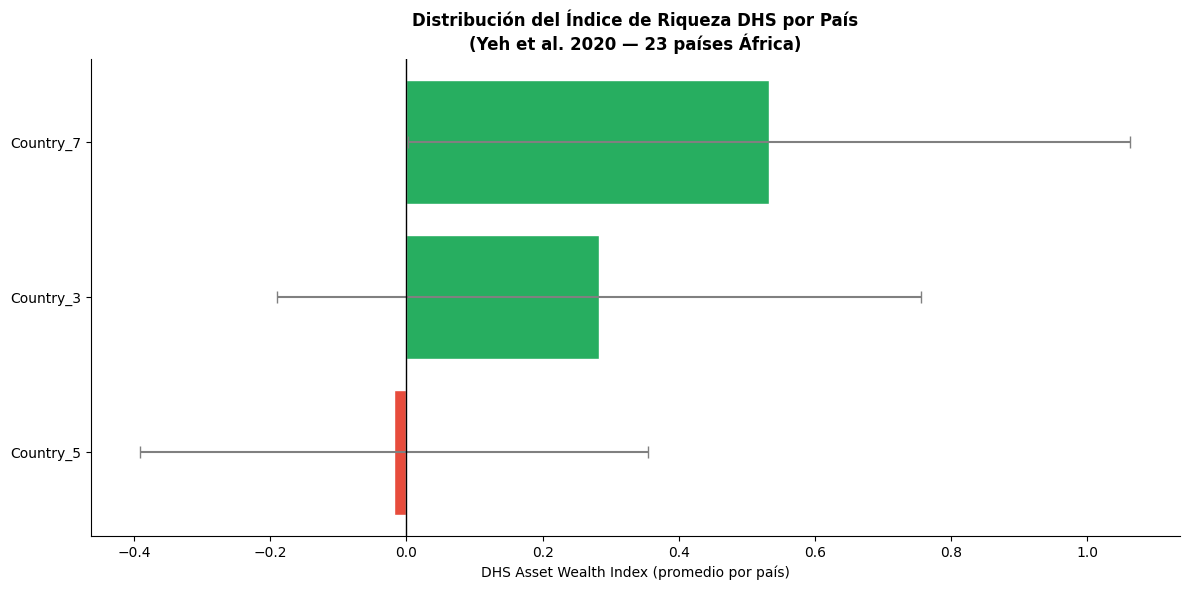

In [1]:
# ═══════════════════════════════════════════════════════════════════ 
# PRÁCTICA 13 — Replicación Yeh et al. 2020 (Nature Communications) 
# ═══════════════════════════════════════════════════════════════════

# CELDA 1.1 — Cargar dataset con metadatos de país 
!pip install datasets -q

import os
import numpy as np
import pandas as pd
import torch 
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader, Dataset
from sklearn.linear_model import Ridge 
from sklearn.metrics import r2_score 
from scipy.stats import pearsonr
from datasets import load_from_disk

# 1. ENCONTRAR Y CARGAR LA RUTA EXACTA
BASE_PATH = "/kaggle/input/datasets/cristiandfc/povertymap-small"
RUTA_KAGGLE = None

# Buscar exactamente dónde está el json dentro de tu carpeta
for root, dirs, files in os.walk('/kaggle/input/'):
    if 'dataset_dict.json' in files:
        RUTA_KAGGLE = root
        break

if RUTA_KAGGLE is None:
    raise FileNotFoundError("El dataset está montado, pero Kaggle aún no termina de cargar los archivos internos. Espera 1 minuto y vuelve a ejecutar.")

print(f"✅ Cargando datos desde: {RUTA_KAGGLE}")
hf_dataset = load_from_disk(RUTA_KAGGLE)

# 2. Wrapper para compatibilidad con la estructura de WILDS
class KagglePovertyDataset(Dataset):
    def __init__(self, hf_subset):
        self.data = hf_subset

    def __len__(self): 
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_key = [k for k in item.keys() if 'imag' in k.lower() or 'pix' in k.lower()][0]
        X = torch.tensor(item[img_key], dtype=torch.float32)
        if X.shape[-1] == 8:
            X = X.permute(2, 0, 1)
            
        lbl_key = [k for k in item.keys() if 'label' in k.lower() or 'wealth' in k.lower()][0]
        y = torch.tensor(item[lbl_key], dtype=torch.float32)
        
        country = item.get('country', 0)
        urban   = item.get('urban', 0)
        meta = torch.tensor([country, urban], dtype=torch.float32)
        return X, y, meta

    @property
    def metadata_array(self):
        countries = self.data['country'] if 'country' in self.data.column_names else [0]*len(self)
        urbans = self.data['urban'] if 'urban' in self.data.column_names else [0]*len(self)
        return torch.tensor(list(zip(countries, urbans)), dtype=torch.float32)

class MockDatasetInfo:
    metadata_map = {"country": [f"Country_{i}" for i in range(50)]} 

# 3. Asignar variables
dataset = MockDatasetInfo()
train_data = KagglePovertyDataset(hf_dataset['train']) 
test_key   = 'test' if 'test' in hf_dataset else list(hf_dataset.keys())[-1]
ood_data   = KagglePovertyDataset(hf_dataset[test_key])

# Los metadatos incluyen: [country_id, urban_rural] 
train_meta = train_data.metadata_array   # tensor (N, 2) 
ood_meta   = ood_data.metadata_array

paises = dataset.metadata_map["country"]   # lista de nombres de país 
print(f"Países en entrenamiento: {len(torch.unique(train_meta[:,0]))}") 
print(f"Países en test OOD:      {len(torch.unique(ood_meta[:,0]))}") 

# Distribución rural/urbano (0: rural, 1: urbano)
counts = torch.unique(train_meta[:,1], return_counts=True)
print(f"Distribución rural/urban: {dict(zip(counts[0].tolist(), counts[1].tolist()))}")

# CELDA 1.2 — Distribución de wealth index por país 
train_loader = DataLoader(train_data, batch_size=256) 
wealth_by_country = {} 
for _, y, meta in train_loader:     
    for country_id, wealth in zip(meta[:,0].numpy(), y.numpy()):         
        cname = paises[int(country_id)]         
        wealth_by_country.setdefault(cname, []).append(wealth)

stats = {k: (np.mean(v), np.std(v)) for k, v in wealth_by_country.items()} 
stats_sorted = dict(sorted(stats.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(12, 6)) 
names  = list(stats_sorted.keys()) 
means  = [v[0] for v in stats_sorted.values()] 
stds   = [v[1] for v in stats_sorted.values()] 
colors = ["#E74C3C" if m<0 else "#27AE60" for m in means] 

ax.barh(names, means, color=colors, edgecolor="white") 
ax.errorbar(means, names, xerr=stds, fmt="none", color="gray", capsize=4) 
ax.axvline(0, color="black", lw=1) 
ax.set_xlabel("DHS Asset Wealth Index (promedio por país)", fontsize=10) 
ax.set_title("Distribución del Índice de Riqueza DHS por País\n(Yeh et al. 2020 — 23 países África)", fontweight="bold") 
ax.spines[["top","right"]].set_visible(False) 
plt.tight_layout() 
plt.savefig("riqueza_por_pais_yeh2020.png", dpi=150, bbox_inches="tight") 
plt.show()

**ACTIVIDAD 2: Generalización LOCO: Leave-One-Country-Out**


In [ ]:
# ═══════════════════════════════════════════════════════════════════ 
# ACTIVIDAD 2 — Validación LOCO (Leave-One-Country-Out) 
# Estrategia central de Yeh et al. 2020 
# ═══════════════════════════════════════════════════════════════════

# CELDA 2.1 — Extraer features ResNet-18 para TODOS los datos 
# (reutilizar de Práctica 12 si ya fue ejecutada) 
import torchvision.models as models 
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

resnet = models.resnet18(weights="IMAGENET1K_V1") 
orig = resnet.conv1 
resnet.conv1 = nn.Conv2d(8, orig.out_channels, orig.kernel_size, orig.stride, orig.padding, bias=False) 
with torch.no_grad():     
    resnet.conv1.weight[:,:3] = orig.weight     
    resnet.conv1.weight[:,3:] = orig.weight.mean(dim=1,keepdim=True).expand(-1,5,-1,-1) 
resnet.fc = nn.Identity() 
resnet = resnet.to(device).eval()

# Extraer features (usar solo 5000 muestras para velocidad en clase) 
def get_features_labels_meta(subset, model, max_n=5000):     
    loader = DataLoader(subset, batch_size=64, shuffle=False)     
    F, Y, M = [], [], []     
    n = 0     
    for X, y, meta in loader:         
        if n >= max_n: break         
        X = X.float().to(device)         
        if X.shape[2] != 224:              
            X = nn.functional.interpolate(X, (224,224))         
        with torch.no_grad():              
            feat = resnet(X).cpu().numpy()         
        F.append(feat); Y.append(y.numpy()); M.append(meta.numpy())         
        n += len(X)     
    return np.vstack(F)[:max_n], np.concatenate(Y)[:max_n], np.vstack(M)[:max_n]

feats_all, y_all, meta_all = get_features_labels_meta(train_data, resnet, 5000)

country_ids = meta_all[:, 0].astype(int) 
unique_countries = np.unique(country_ids) 
print(f"✅ Features extraídas para {len(unique_countries)} países")

# CELDA 2.2 — LOCO Cross-Validation 
loco_results = {} 
for held_out in unique_countries[:8]:   # evaluar primeros 8 países     
    train_mask = country_ids != held_out     
    test_mask  = country_ids == held_out     
    if test_mask.sum() < 10: continue

    X_tr, y_tr = feats_all[train_mask], y_all[train_mask]     
    X_te, y_te = feats_all[test_mask],  y_all[test_mask]

    ridge = Ridge(alpha=1.0).fit(X_tr, y_tr)     
    y_hat = ridge.predict(X_te)

    r = pearsonr(y_te, y_hat)[0]     
    r2 = r2_score(y_te, y_hat)     
    cname = paises[held_out] if held_out < len(paises) else f"País {held_out}"     
    loco_results[cname] = {"r": r, "r2": r2, "n": test_mask.sum()}     
    print(f"  {cname:20s}: r={r:.3f}  R²={r2:.3f} (n={test_mask.sum()})")

# CELDA 2.3 — Gráfico comparativo LOCO vs paper 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names_l = list(loco_results.keys()) 
r_vals  = [loco_results[n]["r"] for n in names_l] 
r2_vals = [loco_results[n]["r2"] for n in names_l]

axes[0].barh(names_l, r_vals, color="#1A5276", edgecolor="white") 
axes[0].axvline(0.70, color="#E74C3C", ls="--", lw=2, label="Paper: r=0.70 promedio") 
axes[0].set_xlabel("r Pearson (LOCO)") 
axes[0].set_title("Pearson r por País (LOCO)\nReplicación Yeh et al. 2020", fontweight="bold") 
axes[0].legend(); axes[0].spines[["top","right"]].set_visible(False)

r_mean = np.mean(r_vals) 
axes[1].scatter([0.70], [r_mean], s=300, c="#E74C3C", zorder=5, label="Comparación") 
axes[1].annotate(f"Paper: r=0.70", xy=(0.70, r_mean-0.05), fontsize=10) 
axes[1].annotate(f"Tuyo:  r={r_mean:.3f}", xy=(0.70, r_mean+0.03), fontsize=10, color="#1B5E20") 
axes[1].set_xlim(0.5, 0.9); axes[1].set_ylim(0.5, 0.9) 
axes[1].plot([0.5,0.9],[0.5,0.9],"--",color="gray")
axes[1].set_xlabel("r Paper") 
axes[1].set_ylabel("r Replicación")
axes[1].set_title("Comparación con Artículo", fontweight="bold") 
axes[1].spines[["top","right"]].set_visible(False) 
plt.tight_layout()
plt.savefig("loco_yeh2020.png", dpi=150, bbox_inches="tight")
plt.show()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s] 


**ACTIVIDAD 3: Comparar Rural vs. Urbano — Figura 2 del paper**


In [ ]:
# ═══════════════════════════════════════════════════════════════════ 
# ACTIVIDAD 3 — Comparar desempeño Rural vs. Urbano 
# Yeh et al. reportan mejor R² en zonas rurales que urbanas 
# ═══════════════════════════════════════════════════════════════════

# CELDA 3.1 — Separar rural (0) vs urbano (1) 
area_ids = meta_all[:, 1].astype(int)

resultados_area = {} 
for area_id, area_name in enumerate(["Rural", "Urbano"]):     
    mask = area_ids == area_id     
    if mask.sum() < 30: continue     
    X_a, y_a = feats_all[mask], y_all[mask]     
    from sklearn.model_selection import cross_val_score     
    scores = cross_val_score(Ridge(alpha=1.0), X_a, y_a, cv=5, scoring="r2")     
    resultados_area[area_name] = {"r2_mean": scores.mean(), "r2_std": scores.std(), "n": mask.sum()}     
    print(f"{area_name}: R²={scores.mean():.3f}±{scores.std():.3f} (n={mask.sum()})")

print("\nPaper Yeh et al. 2020:") 
print("  Rural:  r=0.75 (mejor desempeño — señales visuales más claras)") 
print("  Urbano: r=0.62 (peor — heterogeneidad intra-urbana alta)")

# CELDA 3.2 — Visualizar diferencia rural vs urbano 
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (area, res) in zip(axes, resultados_area.items()):     
    mask = area_ids == (0 if area=="Rural" else 1)     
    y_pred_a = Ridge(alpha=1.0).fit(feats_all[~mask], y_all[~mask]).predict(feats_all[mask])     
    ax.scatter(y_all[mask], y_pred_a, alpha=0.3, s=12, c="#1A5276")     
    lim = [y_all[mask].min()-0.1, y_all[mask].max()+0.1]     
    ax.plot(lim, lim, "--", color="#E74C3C", lw=2)     
    ax.set_xlabel("Wealth Index Observado"); ax.set_ylabel("Predicho")     
    ax.set_title(f"{area}\nR²={res['r2_mean']:.3f} | n={res['n']}", fontweight="bold")     
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Desempeño Rural vs. Urbano — Yeh et al. 2020", fontweight="bold", fontsize=12) 
plt.tight_layout()
plt.savefig("rural_urbano_yeh2020.png", dpi=150, bbox_inches="tight")
plt.show()

# V. PREGUNTAS DE REFLEXIÓN

**1. Yeh et al. obtienen r=0.75 en rural y r=0.62 en urbano. Explica desde la teoría por qué el modelo funciona MEJOR en zonas rurales. ¿Esto es un problema para aplicar el método en Lima o Arequipa?**

El modelo satelital funciona mucho mejor en zonas rurales porque allí **la riqueza y la morfología física están directamente correlacionadas**. Un hogar rural más rico se hace evidente desde el espacio: reemplaza el techo de paja por metal (cambio drástico de reflectancia), amplía el tamaño de la parcela agrícola o construye un camino de acceso visible. 

En contraste, el peor desempeño en zonas urbanas (r=0.62) se debe a la **extrema heterogeneidad intra-urbana**. En las ciudades, la pobreza y la riqueza coexisten en áreas muy pequeñas (por ejemplo, barrios de clase media justo al lado de invasiones). Además, a una resolución satelital de 30 metros, el techo de concreto de un departamento de lujo se ve espectralmente casi igual al techo de cemento de una vivienda precaria. 
**Sí, esto es un problema crítico para Lima o Arequipa.** En estas metrópolis, gran parte de la pobreza es "invisible" desde el cielo (problemas de hacinamiento interno, falta de titulación o servicios básicos) a pesar de que la estructura externa parezca consolidada, lo que provocaría que el modelo sobreestime sistemáticamente la riqueza de los cinturones periféricos.

---

**2. El modelo fue entrenado en 23 países africanos y aún así generaliza bien (r=0.70 OOD). ¿Qué características visuales crees que son "universales" entre países y cuáles son específicas de cada región?**

La capacidad de *domain generalization* de la red neuronal convolucional (ResNet-18) recae en su habilidad para extraer características estructurales de alto nivel.
*   **Características "Universales" (Las que el modelo usa para generalizar):** La densidad de la construcción (píxeles urbanizados vs. suelo desnudo), la geometría ortogonal de las redes viales asfaltadas, la presencia de luces nocturnas potentes (indicativo de electrificación o industria), y los grandes cuerpos de agua e infraestructura portuaria. Estas son las heurísticas que la red aprendió a asociar con el progreso.
*   **Características "Específicas de Región" (Las que el modelo ignora o lo confunden):** El color de la tierra (laterita roja en partes de África vs. tonos grises en otras), la arquitectura vernácula (tejados inclinados vs. planos según el régimen de lluvias local), y la vegetación específica del ecosistema (sabanas frente a bosques tropicales húmedos).

---

**3. Para aplicar este modelo a Perú sin re-entrenamiento, ¿qué tan confiable sería el resultado? Menciona 3 factores que podrían afectar la generalización de África a los Andes peruanos.**

Aplicar un modelo entrenado en 23 países africanos directamente a Perú *Zero-Shot* (sin re-entrenamiento) **sería altamente poco confiable**. Esto se debe a un problema clásico de *Domain Shift* (desplazamiento de dominio), donde la distribución de las imágenes de prueba es drásticamente distinta a las de entrenamiento. Los 3 factores principales que destruirían la generalización son:

1.  **Topografía y Sombras:** Los Andes peruanos tienen una orografía extrema. Las montañas generan sombras y distorsiones geométricas en las imágenes satelitales que la red (entrenada mayormente en llanuras y sabanas africanas) interpretará como ruido o falsos bordes urbanos.
2.  **Patrones de Urbanización e Informalidad:** La estructura de la pobreza en Perú es radicalmente distinta. En América Latina está altamente urbanizada en laderas (invasiones), mientras que la pobreza en África es predominantemente de distribución rural plana. 
3.  **Estructura Económica (Economías de Enclave):** En los Andes, la presencia de socavones o relaves mineros de gran escala podría confundir a la IA. La red podría asociar las carreteras y excavaciones masivas de una mina andina con prosperidad urbana, cuando en realidad las comunidades aledañas padecen altos niveles de pobreza multidimensional.

In [ ]:
import joblib
import torch
import zipfile
import os
from sklearn.linear_model import Ridge
from IPython.display import FileLink, display

# 1. Guardar extractor, modelo final (todos los datos) y escalador
torch.save(resnet.state_dict(), "extractor_resnet18_p13.pth")
ridge_final = Ridge(alpha=1.0).fit(feats_all, y_all)
joblib.dump(ridge_final, "predictor_ridge_p13.pkl")
joblib.dump(scaler_all, "scaler_p13.pkl")

# 2. Comprimir todo en un ZIP
archivos_p13 = ["extractor_resnet18_p13.pth", "predictor_ridge_p13.pkl", "scaler_p13.pkl"]
nombre_zip_p13 = "despliegue_p13.zip"

with zipfile.ZipFile(nombre_zip_p13, "w") as zf:
    for f in archivos_p13:
        if os.path.exists(f): zf.write(f)

# 3. Generar enlace de descarga
print("✅ Listo. Haz clic en el enlace para descargar:")
display(FileLink(nombre_zip_p13))